In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint

# As the dataset is divided into folders
from tensorflow.keras.preprocessing.image import ImageDataGenerator

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
w,h = 400,400
batch_size = 32

train_path = '/kaggle/input/chest-xray-pneumoniacovid19tuberculosis/train'
test_path = '/kaggle/input/chest-xray-pneumoniacovid19tuberculosis/test'
val_path = '/kaggle/input/chest-xray-pneumoniacovid19tuberculosis/val'

train_img_gen = ImageDataGenerator(
    rescale = 1.0/255,
    zoom_range=0.3
)

test_img_gen = ImageDataGenerator(
    rescale = 1.0/255
)

val_img_gen = ImageDataGenerator(
    rescale = 1.0/255
)

train_dataset = train_img_gen.flow_from_directory(
    train_path,
    target_size = (w,h),
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = True
)

test_dataset = test_img_gen.flow_from_directory(
    test_path,
    target_size = (w,h),
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

val_dataset = val_img_gen.flow_from_directory(
    val_path,
    target_size = (w,h),
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 6326 images belonging to 4 classes.
Found 771 images belonging to 4 classes.
Found 38 images belonging to 4 classes.


In [3]:
train_dataset.class_indices

{'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TURBERCULOSIS': 3}

(32, 400, 400, 3)


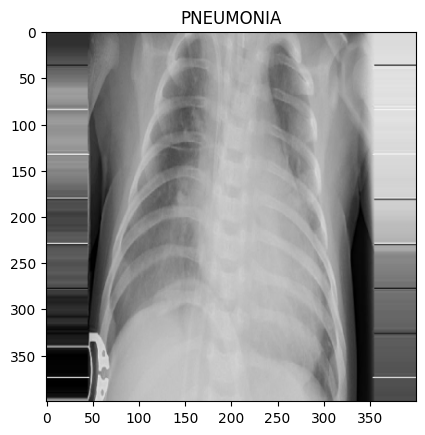

(32, 400, 400, 3)


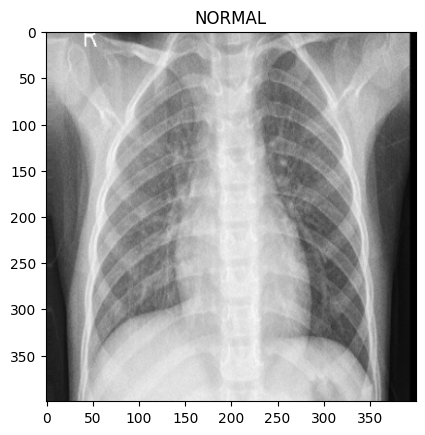

(32, 400, 400, 3)


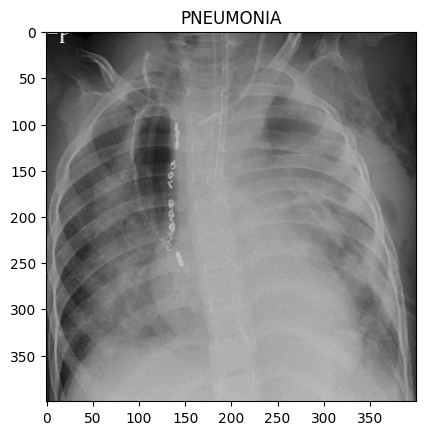

(32, 400, 400, 3)


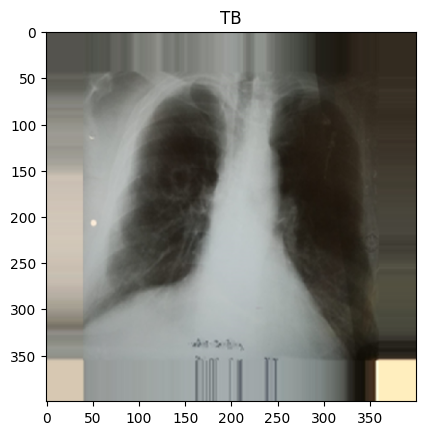

(32, 400, 400, 3)


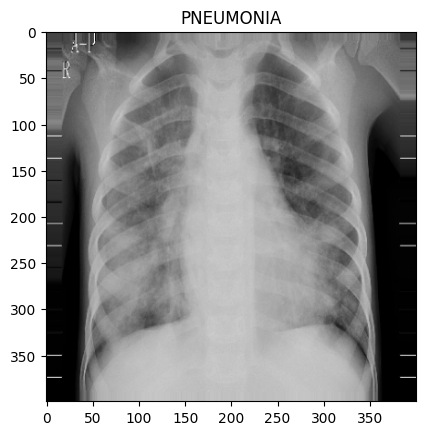

In [4]:
classes = ['COVID19', 'NORMAL', 'PNEUMONIA', 'TB']

for _ in range(5):
    img, label = train_dataset.next()
    print(img.shape)
    plt.title(classes[np.argmax(label[0])])
    plt.imshow(img[0])
    plt.show()

In [5]:
train_dataset.image_shape

(400, 400, 3)

In [6]:
def freeze_first_layers(base_model, trainable_ratio=0.2):
    """
    Đóng băng các tầng đầu, chỉ cho các tầng sau học.
    trainable_ratio = 0.2 nghĩa là chỉ mở 20% tầng cuối để huấn luyện.
    """
    base_model.trainable = True

    total_layers = len(base_model.layers)
    freeze_until = int(total_layers * (1 - trainable_ratio))

    for layer in base_model.layers[:freeze_until]:
        layer.trainable = False

    for layer in base_model.layers[freeze_until:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    print(f"Tổng số tầng: {total_layers}")
    print(f"Đóng băng: {freeze_until} tầng đầu")
    print(f"Cho học: {total_layers - freeze_until} tầng cuối")

In [7]:
resnetModel = models.Sequential()

ResNet_101_V2 = tf.keras.applications.ResNet101V2(
    include_top=False,
    weights="imagenet",
    input_shape=(w, h, 3),
    pooling='max'
)

freeze_first_layers(ResNet_101_V2, trainable_ratio=0.3)

resnetModel.add(ResNet_101_V2)
resnetModel.add(layers.Flatten())
resnetModel.add(layers.Dense(512, activation='relu'))
resnetModel.add(layers.Dropout(0.5))
resnetModel.add(layers.Dense(4, activation='softmax'))

resnetModel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnetModel.summary()

171317808/171317808 [==============================] - 1s 0us/step
Tổng số tầng: 378
Đóng băng: 264 tầng đầu
Cho học: 114 tầng cuối
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 2048)              42626560  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 2052      
                                                                 
Total params: 43,677,700
Trainable params: 23,807,492
No

In [8]:
weight_path = '/kaggle/working/'

def get_checkpoint(model_name):
    checkpoint_file = weight_path + model_name + '_best.weights.h5'

    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_file,
        save_best_only=True,
        save_weights_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    )

    return model_checkpoint

In [9]:
history_resnet = resnetModel.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[get_checkpoint('resnet')]
)

Epoch 1/10
198/198 [==============================] - ETA: 0s - loss: 0.5405 - accuracy: 0.8381
Epoch 1: val_loss improved from inf to 0.25813, saving model to /kaggle/working/resnet_best.weights.h5
198/198 [==============================] - 363s 2s/step - loss: 0.5405 - accuracy: 0.8381 - val_loss: 0.2581 - val_accuracy: 0.9211
Epoch 2/10
198/198 [==============================] - ETA: 0s - loss: 0.1756 - accuracy: 0.9349
Epoch 2: val_loss did not improve from 0.25813
198/198 [==============================] - 270s 1s/step - loss: 0.1756 - accuracy: 0.9349 - val_loss: 0.4647 - val_accuracy: 0.8684
Epoch 3/10
198/198 [==============================] - ETA: 0s - loss: 0.1237 - accuracy: 0.9568
Epoch 3: val_loss improved from 0.25813 to 0.18589, saving model to /kaggle/working/resnet_best.weights.h5
198/198 [==============================] - 271s 1s/step - loss: 0.1237 - accuracy: 0.9568 - val_loss: 0.1859 - val_accuracy: 0.9211
Epoch 4/10
198/198 [==============================] - ETA: 

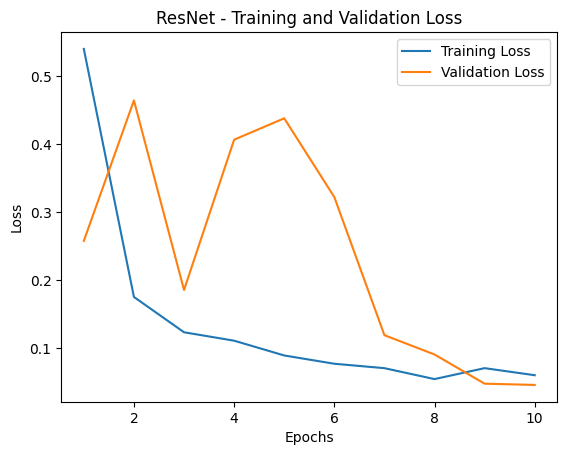

In [10]:
loss = history_resnet.history['loss']
val_loss = history_resnet.history['val_loss']
epochs = len(history_resnet.history['loss'])

epochs_range = range(1, epochs + 1)

plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet - Training and Validation Loss')
plt.legend()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import os

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [12]:
def evaluate_model(model, model_display_name, weight_file):
    """
    Đánh giá mô hình trên tập test_dataset có sẵn.
    """

    # Kiểm tra file weight có tồn tại không
    if not os.path.exists(weight_file):
        print(f"Không tìm thấy file weight: {weight_file}")
        return None, None, None

    # Load weight tốt nhất
    model.load_weights(weight_file)

    # Reset test dataset để thứ tự ảnh không bị lệch
    test_dataset.reset()

    # Dự đoán
    y_prob = model.predict(test_dataset, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    # Nhãn thật
    y_true = test_dataset.classes

    # Tính các chỉ số đánh giá
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    result = {
        "Model": model_display_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    return result, y_true, y_pred

In [13]:
results = []
# ResNet101
result_resnet, y_true_resnet, y_pred_resnet = evaluate_model(
    resnetModel,
    "ResNet101V2",
    "/kaggle/working/resnet_best.weights.h5"
)

if result_resnet is not None:
    results.append(result_resnet)

25/25 [==============================] - 23s 822ms/step


In [14]:
import pandas as pd

# Tạo bảng kết quả từ list results
results_df = pd.DataFrame(results)

# Kiểm tra có dữ liệu không
print(results_df)

         Model  Accuracy  Precision    Recall  F1-score
0  ResNet101V2  0.948119   0.963359  0.956805  0.959712


In [15]:
results_df_sorted = results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

results_df_sorted

,Model,Accuracy,Precision,Recall,F1-score
0,ResNet101V2,0.948119,0.963359,0.956805,0.959712


In [16]:
best_model_row = results_df_sorted.iloc[0]

best_model_name = best_model_row["Model"]
best_f1 = best_model_row["F1-score"]

print("Mô hình tốt nhất là:", best_model_name)
print("F1-score:", best_f1)

Mô hình tốt nhất là: ResNet101V2
F1-score: 0.959711706040417


In [17]:
class_names = list(test_dataset.class_indices.keys())

print("Class names:", class_names)
print("Class indices:", test_dataset.class_indices)

Class names: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Class indices: {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TURBERCULOSIS': 3}


In [18]:
# Lấy 1 batch ảnh từ test_dataset
images, labels = test_dataset[0]

# Chọn ảnh đầu tiên trong batch
sample_img = images[0]
sample_label = labels[0]

# Tạo input cho model, shape: (1, 400, 400, 3)
img_array = np.expand_dims(sample_img, axis=0)

# Dự đoán ảnh mẫu
pred = resnetModel.predict(img_array, verbose=0)

pred_index = np.argmax(pred[0])
true_index = np.argmax(sample_label)

print("img_array shape:", img_array.shape)
print("Nhãn thật:", class_names[true_index])
print("Dự đoán:", class_names[pred_index])
print("Độ tin cậy:", np.max(pred[0]) * 100)

img_array shape: (1, 400, 400, 3)
Nhãn thật: COVID19
Dự đoán: COVID19
Độ tin cậy: 99.99710321426392


In [27]:
import tensorflow as tf
import numpy as np

def get_resnet_base_model(model):
    """
    Tìm model con ResNet101 bên trong model chính.
    """
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            if "resnet" in layer.name.lower():
                return layer
    
    raise ValueError("Không tìm thấy ResNet model con bên trong resnetModel.")


def get_last_conv_layer_from_base(base_model):
    """
    Tìm layer convolution cuối cùng trong ResNet101.
    """
    for layer in reversed(base_model.layers):
        if len(layer.output.shape) == 4:
            return layer
    
    raise ValueError("Không tìm thấy convolution layer cuối trong ResNet101.")


def build_xai_grad_model(model):
    """
    Tạo Grad-CAM model cho trường hợp model có dạng:
    Input -> ResNet101 -> GlobalAveragePooling -> Dense -> Output
    """
    base_model = get_resnet_base_model(model)
    last_conv_layer = get_last_conv_layer_from_base(base_model)

    print("Base model:", base_model.name)
    print("Last conv layer:", last_conv_layer.name)

    # Model phụ lấy feature map cuối và output của ResNet101
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    # Tạo input mới theo input của model chính
    inputs = model.input

    # Chạy input qua ResNet101 để lấy feature map và output của base model
    conv_output, x = conv_model(inputs)

    # Tìm vị trí của ResNet101 trong model chính
    base_index = None
    for i, layer in enumerate(model.layers):
        if layer.name == base_model.name:
            base_index = i
            break

    if base_index is None:
        raise ValueError("Không xác định được vị trí ResNet101 trong model chính.")

    # Chạy tiếp các layer phía sau ResNet101
    for layer in model.layers[base_index + 1:]:
        x = layer(x)

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[
            conv_output,
            x
        ]
    )

    return grad_model

In [28]:
xai_grad_model = build_xai_grad_model(resnetModel)

conv_test, pred_test = xai_grad_model(img_array, training=False)

print("Tạo XAI model thành công")
print("Feature map shape:", conv_test.shape)
print("Prediction shape:", pred_test.shape)

original_pred = resnetModel.predict(img_array, verbose=0)
xai_pred = pred_test.numpy()

print("Sai lệch dự đoán:", np.max(np.abs(original_pred - xai_pred)))

Base model: resnet101v2
Last conv layer: post_relu
Tạo XAI model thành công
Feature map shape: (1, 13, 13, 2048)
Prediction shape: (1, 4)
Sai lệch dự đoán: 8.185452e-11


In [29]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [30]:
resnetModel.load_weights('/kaggle/working/resnet_best.weights.h5')

class_names = list(test_dataset.class_indices.keys())

print("Đã load model ResNet101V2")
print("Class names:", class_names)

Đã load model ResNet101V2
Class names: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']


In [31]:
def find_last_conv_layer(model):
    """
    Tìm lớp Conv2D cuối cùng trong model, kể cả khi backbone nằm bên trong Sequential.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer
        
        if isinstance(layer, tf.keras.Model):
            for sub_layer in reversed(layer.layers):
                if isinstance(sub_layer, tf.keras.layers.Conv2D):
                    return sub_layer

    raise ValueError("Không tìm thấy lớp Conv2D trong model.")

last_conv_layer = find_last_conv_layer(resnetModel)
print("Last conv layer:", last_conv_layer.name)

Last conv layer: conv5_block3_3_conv


In [33]:
def normalize_image(img):
    """
    Đưa ảnh về khoảng 0-1 để hiển thị.
    """
    img = img.astype("float32")
    img_min = img.min()
    img_max = img.max()

    if img_max - img_min < 1e-8:
        return np.zeros_like(img)

    return (img - img_min) / (img_max - img_min)


def normalize_heatmap(heatmap):
    """
    Chuẩn hóa heatmap về khoảng 0-1.
    """
    heatmap = np.maximum(heatmap, 0)
    max_value = np.max(heatmap)

    if max_value == 0:
        return heatmap

    return heatmap / max_value


def overlay_heatmap(image, heatmap, alpha=0.45):
    """
    Chồng heatmap lên ảnh X-quang.
    """
    image = normalize_image(image)

    if image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = normalize_heatmap(heatmap)

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_color = heatmap_color.astype("float32") / 255.0

    overlay = (1 - alpha) * image + alpha * heatmap_color
    overlay = np.clip(overlay, 0, 1)

    return overlay

In [34]:
def make_gradcam_heatmap(img_array, grad_model, class_index=None):
    """
    Tạo heatmap Grad-CAM bằng xai_grad_model.
    """

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = heatmap.numpy()

    return normalize_heatmap(heatmap)

In [38]:
def make_gradcam_plus_plus_heatmap(img_array, grad_model, class_index=None):
    """
    Tạo heatmap Grad-CAM++ bằng xai_grad_model.
    """

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)

    conv_outputs = conv_outputs[0]
    grads = grads[0]

    grads_power_2 = tf.square(grads)
    grads_power_3 = grads_power_2 * grads

    sum_conv_outputs = tf.reduce_sum(conv_outputs, axis=(0, 1))

    eps = 1e-8

    alpha_num = grads_power_2
    alpha_den = 2.0 * grads_power_2 + sum_conv_outputs * grads_power_3
    alpha_den = tf.where(alpha_den != 0.0, alpha_den, eps)

    alphas = alpha_num / alpha_den

    positive_grads = tf.nn.relu(grads)

    weights = tf.reduce_sum(alphas * positive_grads, axis=(0, 1))

    heatmap = tf.reduce_sum(weights * conv_outputs, axis=-1)
    heatmap = heatmap.numpy()

    return normalize_heatmap(heatmap)

In [39]:
def make_integrated_gradients_heatmap(
    img_array,
    model,
    class_index=None,
    steps=16,
    batch_size=4
):
    """
    Integrated Gradients bản tiết kiệm GPU RAM.
    Không đưa toàn bộ steps vào model cùng lúc.
    """

    img = tf.cast(img_array[0], tf.float32)

    if class_index is None:
        pred = model.predict(img_array, verbose=0)
        class_index = np.argmax(pred[0])

    baseline = tf.zeros_like(img)
    alphas = tf.linspace(0.0, 1.0, steps)

    total_grads = tf.zeros_like(img)

    for start in range(0, steps, batch_size):
        end = min(start + batch_size, steps)
        alpha_batch = alphas[start:end]

        interpolated_images = []

        for alpha in alpha_batch:
            interpolated = baseline + alpha * (img - baseline)
            interpolated_images.append(interpolated)

        interpolated_images = tf.stack(interpolated_images)

        with tf.GradientTape() as tape:
            tape.watch(interpolated_images)
            predictions = model(interpolated_images, training=False)
            target_scores = predictions[:, class_index]

        grads = tape.gradient(target_scores, interpolated_images)

        total_grads += tf.reduce_sum(grads, axis=0)

    avg_grads = total_grads / tf.cast(steps, tf.float32)

    integrated_grads = (img - baseline) * avg_grads

    heatmap = tf.reduce_sum(tf.abs(integrated_grads), axis=-1)
    heatmap = heatmap.numpy()

    return normalize_heatmap(heatmap)

In [40]:
def make_occlusion_sensitivity_heatmap(
    img_array,
    model,
    class_index=None,
    patch_size=50,
    stride=50,
    occlusion_value=0.0,
    batch_size=16
):
    """
    Tạo heatmap Occlusion Sensitivity.
    """
    if class_index is None:
        pred = model.predict(img_array, verbose=0)
        class_index = np.argmax(pred[0])

    original_pred = model.predict(img_array, verbose=0)[0]
    original_score = original_pred[class_index]

    _, h, w, c = img_array.shape

    occluded_images = []
    coordinates = []

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y1 = y
            y2 = min(y + patch_size, h)
            x1 = x
            x2 = min(x + patch_size, w)

            occluded = img_array.copy()
            occluded[:, y1:y2, x1:x2, :] = occlusion_value

            occluded_images.append(occluded[0])
            coordinates.append((y1, y2, x1, x2))

    occluded_images = np.array(occluded_images)

    occluded_preds = model.predict(
        occluded_images,
        batch_size=batch_size,
        verbose=0
    )

    heatmap = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    for pred, coord in zip(occluded_preds, coordinates):
        y1, y2, x1, x2 = coord

        new_score = pred[class_index]
        score_drop = original_score - new_score

        if score_drop < 0:
            score_drop = 0

        heatmap[y1:y2, x1:x2] += score_drop
        count_map[y1:y2, x1:x2] += 1

    heatmap = heatmap / np.maximum(count_map, 1)

    return normalize_heatmap(heatmap)

In [41]:
# Lấy một batch từ test dataset
images, labels = test_dataset[0]

# Chọn ảnh đầu tiên trong batch
sample_img = images[0]
sample_label = labels[0]

img_array = np.expand_dims(sample_img, axis=0)

# Dự đoán
pred = resnetModel.predict(img_array, verbose=0)

pred_index = np.argmax(pred[0])
true_index = np.argmax(sample_label)

print("Nhãn thật:", class_names[true_index])
print("Dự đoán:", class_names[pred_index])
print("Độ tin cậy:", np.max(pred[0]) * 100)

Nhãn thật: COVID19
Dự đoán: COVID19
Độ tin cậy: 99.99710321426392


In [42]:
target_class = pred_index

gradcam_heatmap = make_gradcam_heatmap(
    img_array,
    xai_grad_model,
    class_index=target_class
)

gradcampp_heatmap = make_gradcam_plus_plus_heatmap(
    img_array,
    xai_grad_model,
    class_index=target_class
)

ig_heatmap = make_integrated_gradients_heatmap(
    img_array,
    resnetModel,
    class_index=target_class,
    steps=16,
    batch_size=4
)

occlusion_heatmap = make_occlusion_sensitivity_heatmap(
    img_array,
    resnetModel,
    class_index=target_class,
    patch_size=80,
    stride=80,
    batch_size=4
)

print("Đã tạo xong 4 heatmap XAI")

Đã tạo xong 4 heatmap XAI


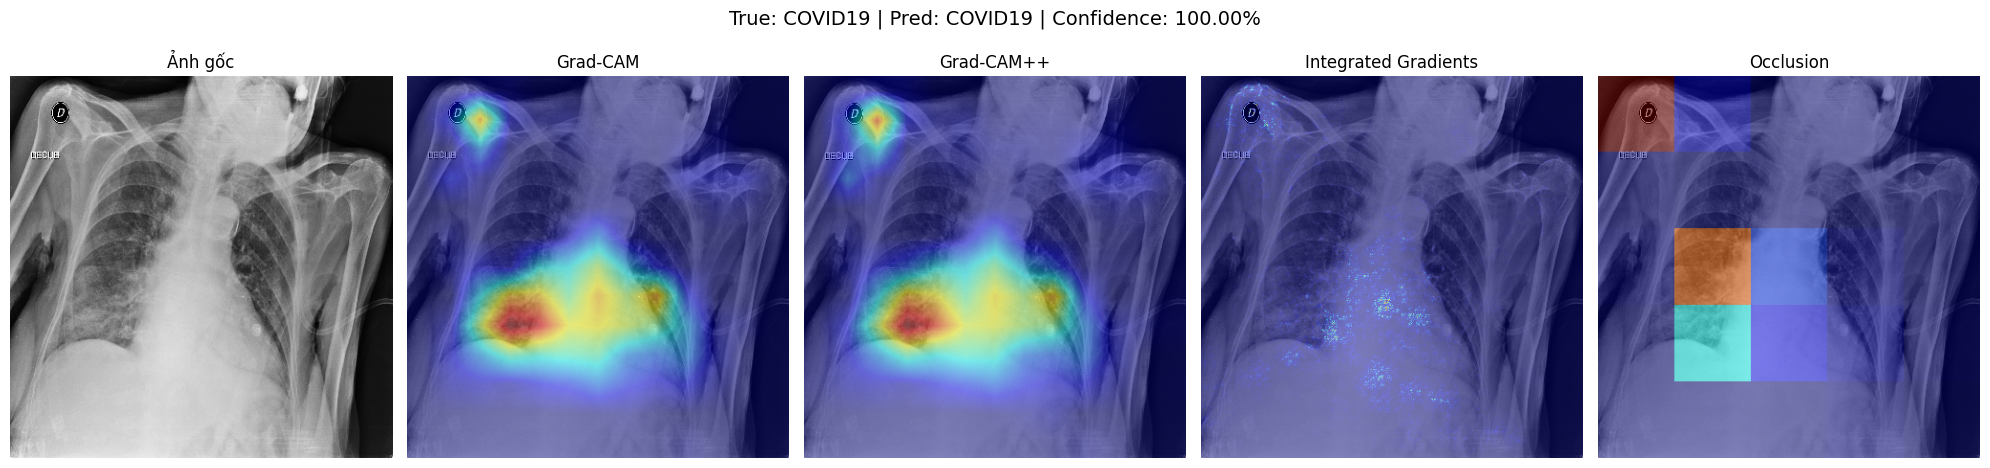

In [43]:
original_img = normalize_image(sample_img)

gradcam_overlay = overlay_heatmap(sample_img, gradcam_heatmap)
gradcampp_overlay = overlay_heatmap(sample_img, gradcampp_heatmap)
ig_overlay = overlay_heatmap(sample_img, ig_heatmap)
occlusion_overlay = overlay_heatmap(sample_img, occlusion_heatmap)

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(original_img)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(gradcam_overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(gradcampp_overlay)
plt.title("Grad-CAM++")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(ig_overlay)
plt.title("Integrated Gradients")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(occlusion_overlay)
plt.title("Occlusion")
plt.axis("off")

plt.suptitle(
    f"True: {class_names[true_index]} | Pred: {class_names[pred_index]} | Confidence: {np.max(pred[0]) * 100:.2f}%",
    fontsize=14
)

plt.tight_layout()
plt.show()

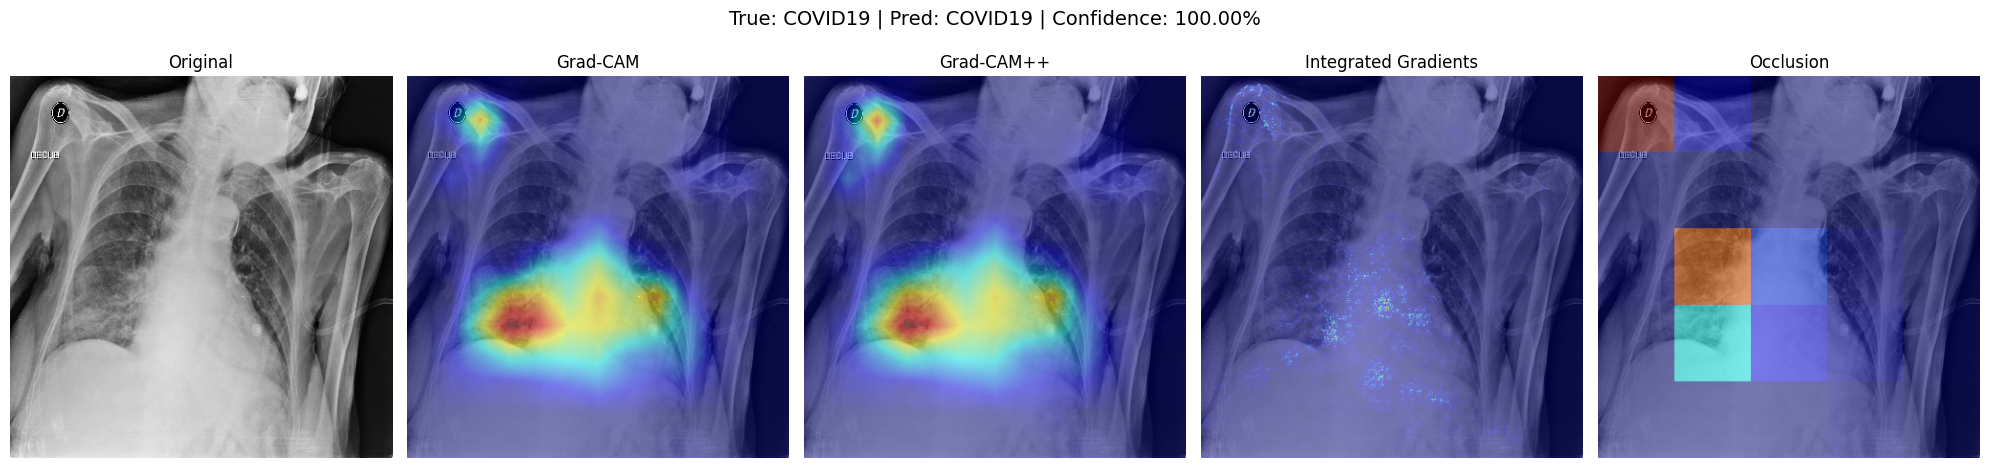

Đã lưu hình tại: /kaggle/working/xai_resnet101v2_result.png


In [44]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(gradcam_overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(gradcampp_overlay)
plt.title("Grad-CAM++")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(ig_overlay)
plt.title("Integrated Gradients")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(occlusion_overlay)
plt.title("Occlusion")
plt.axis("off")

plt.suptitle(
    f"True: {class_names[true_index]} | Pred: {class_names[pred_index]} | Confidence: {np.max(pred[0]) * 100:.2f}%",
    fontsize=14
)

plt.tight_layout()

save_path = "/kaggle/working/xai_resnet101v2_result.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu hình tại:", save_path)

In [45]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Reset test dataset để dự đoán đúng thứ tự ảnh
test_dataset.reset()

# Dự đoán toàn bộ tập test
predictions = resnetModel.predict(test_dataset, verbose=1)

# Nhãn dự đoán
y_pred = np.argmax(predictions, axis=1)

# Nhãn thật
y_true = test_dataset.classes

# Tên lớp
class_names = list(test_dataset.class_indices.keys())

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Đã tạo confusion matrix")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

25/25 [==============================] - 16s 583ms/step
Đã tạo confusion matrix
[[102   2   1   1]
 [  0 209  25   0]
 [  0  11 379   0]
 [  0   0   0  41]]

Classification Report:
               precision    recall  f1-score   support

      COVID19       1.00      0.96      0.98       106
       NORMAL       0.94      0.89      0.92       234
    PNEUMONIA       0.94      0.97      0.95       390
TURBERCULOSIS       0.98      1.00      0.99        41

     accuracy                           0.95       771
    macro avg       0.96      0.96      0.96       771
 weighted avg       0.95      0.95      0.95       771



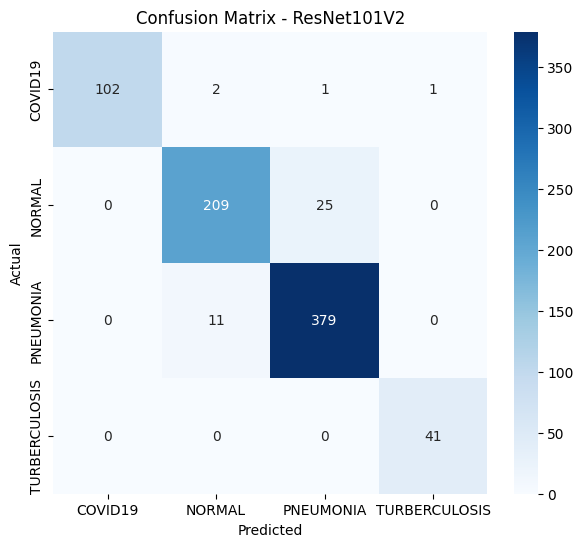

Đã lưu confusion matrix tại: /kaggle/working/confusion_matrix_resnet101v2.png


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_path = "/kaggle/working/confusion_matrix_resnet101v2.png"

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - ResNet101V2")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Đã lưu confusion matrix tại:", cm_path)

In [47]:
resnetModel.save('/kaggle/working/resnet101v2_xray_model.keras')

print("Đã lưu model hoàn chỉnh")

Đã lưu model hoàn chỉnh


In [48]:
import os

files = [
    "/kaggle/working/resnet101v2_xray_model.keras",
    "/kaggle/working/confusion_matrix_resnet101v2.png",
    "/kaggle/working/xai_resnet101v2_result.png",
    "/kaggle/working/resnet_best.weights.h5"
]

for f in files:
    print(f, "=>", os.path.exists(f))

/kaggle/working/resnet101v2_xray_model.keras => True
/kaggle/working/confusion_matrix_resnet101v2.png => True
/kaggle/working/xai_resnet101v2_result.png => True
/kaggle/working/resnet_best.weights.h5 => True


In [49]:
import os
import zipfile

zip_path = "/kaggle/working/resnet101v2_xray_results.zip"

files_to_zip = [
    "/kaggle/working/resnet101v2_xray_model.keras",
    "/kaggle/working/confusion_matrix_resnet101v2.png",
    "/kaggle/working/xai_resnet101v2_result.png",
    "/kaggle/working/resnet_best.weights.h5"
]

with zipfile.ZipFile(zip_path, "w") as zipf:
    for file_path in files_to_zip:
        if os.path.exists(file_path):
            zipf.write(file_path, os.path.basename(file_path))
            print("Đã thêm:", file_path)
        else:
            print("Không tìm thấy, bỏ qua:", file_path)

print("Đã tạo file zip tại:", zip_path)

Đã thêm: /kaggle/working/resnet101v2_xray_model.keras
Đã thêm: /kaggle/working/confusion_matrix_resnet101v2.png
Đã thêm: /kaggle/working/xai_resnet101v2_result.png
Đã thêm: /kaggle/working/resnet_best.weights.h5
Đã tạo file zip tại: /kaggle/working/resnet101v2_xray_results.zip


In [50]:
import os

zip_path = "/kaggle/working/resnet101v2_xray_results.zip"

print("Zip exists:", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("Size:", os.path.getsize(zip_path) / (1024 * 1024), "MB")

Zip exists: True
Size: 702.6632966995239 MB


In [51]:
import os
from IPython.display import FileLink, display

os.chdir("/kaggle/working")

display(FileLink("resnet101v2_xray_results.zip"))

/kaggle/working/resnet101v2_xray_results.zip